<a href="https://colab.research.google.com/github/cchan555/lis4693/blob/main/lab-7/ChanLab7April42026.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 7: Sentiment Analysis
Cody Chan

## Task 1:
Use same dataset from "lab-4" and perform sentiment analysis.

In [19]:
#
# Setup for Lab 7
#

# Import Libraries
import re
import pandas as pd
import matplotlib.pyplot as plt
import nltk
from nltk.sentiment.vader import SentimentIntensityAnalyzer
nltk.download('vader_lexicon')

# Load in Data
import requests
import io

url = "https://raw.githubusercontent.com/cchan555/lis4693/refs/heads/main/lab-4/sms%2Bspam%2Bcollection/SMSSpamCollection"
response = requests.get(url)
response.raise_for_status()
text = response.text

# Dataset is different from notes, need to add in tab separations
df = pd.read_csv(io.StringIO(text),
                 sep = '\t', # Tab separation
                 header = None,
                 names = ['Label', 'Message']) # Add names for each columns
print(df.head())

  Label                                            Message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


[nltk_data] Downloading package vader_lexicon to /root/nltk_data...
[nltk_data]   Package vader_lexicon is already up-to-date!


In [20]:
# Create new Dataframe with "id" and "text"
df_subset = df[['Label', 'Message']].copy()
df_subset = df_subset.reset_index()

# Clean text
df_subset['Message'] = df_subset['Message'].str.replace("[^a-zA-Z#]", "   ")

# Convert to Lower-case
df_subset['Message'] = df_subset['Message'].str.casefold()
print(df_subset.head(10))

   index Label                                            Message
0      0   ham  go until jurong point, crazy.. available only ...
1      1   ham                      ok lar... joking wif u oni...
2      2  spam  free entry in 2 a wkly comp to win fa cup fina...
3      3   ham  u dun say so early hor... u c already then say...
4      4   ham  nah i don't think he goes to usf, he lives aro...
5      5  spam  freemsg hey there darling it's been 3 week's n...
6      6   ham  even my brother is not like to speak with me. ...
7      7   ham  as per your request 'melle melle (oru minnamin...
8      8  spam  winner!! as a valued network customer you have...
9      9  spam  had your mobile 11 months or more? u r entitle...


In [21]:
# Generate Sentiment Polarity Score
df1 = pd.DataFrame()
df1['Label'] = ['9999999999999']
df1['sentiment_type'] = 'NA99NA'
df1['sentiment_score'] = 0
print('Processing sentiment analysis...')
sid = SentimentIntensityAnalyzer()

all_scores_list = [] # Use a list to collect results

for index, row in df_subset.iterrows():
    scores = sid.polarity_scores(row['Message']) # Access by column name for clarity and robustness
    for key, value in scores.items():
        all_scores_list.append({
            'index': row['index'], # Access by column name
            'sentiment_type': key,
            'sentiment_score': value
        })

# Filter for compound sentiment and remove duplicates
t_df_cleaned = pd.DataFrame(all_scores_list)
print(t_df_cleaned.head(10))

df_output = pd.merge(df_subset, t_df_cleaned, on='index')
print(df_output.head(10))

Processing sentiment analysis...
   index sentiment_type  sentiment_score
0      0            neg           0.0000
1      0            neu           0.8060
2      0            pos           0.1940
3      0       compound           0.6249
4      1            neg           0.0000
5      1            neu           0.4230
6      1            pos           0.5770
7      1       compound           0.4767
8      2            neg           0.0000
9      2            neu           0.7720
   index Label                                            Message  \
0      0   ham  go until jurong point, crazy.. available only ...   
1      0   ham  go until jurong point, crazy.. available only ...   
2      0   ham  go until jurong point, crazy.. available only ...   
3      0   ham  go until jurong point, crazy.. available only ...   
4      1   ham                      ok lar... joking wif u oni...   
5      1   ham                      ok lar... joking wif u oni...   
6      1   ham                   

<Axes: title={'center': 'Sentiment Score'}, xlabel='Type of Message', ylabel='Mean Sentiment Score'>

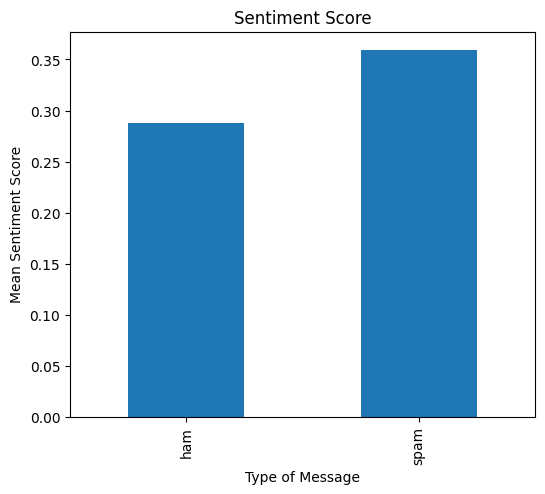

In [22]:
# Visualize Sentiment Analysis Output
df_output[["sentiment_score"]].describe()

# Generate mean of sentiment_score by Message Type
dfg = df_output.groupby(['Label'])['sentiment_score'].mean()
dfg.index = dfg.index.astype(str).str.replace(r'\.0$', '', regex=True)
# Create a bar plot
dfg.plot(kind='bar', title='Sentiment Score', ylabel='Mean Sentiment Score',
         xlabel='Type of Message', figsize=(6, 5))

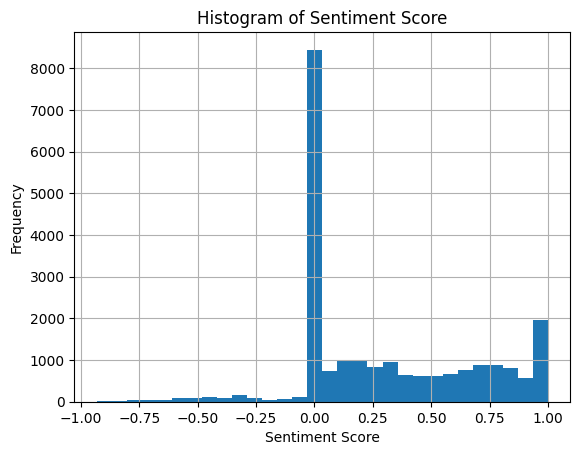

In [23]:
# Create a Histogram plot
df_output['sentiment_score'].hist(bins = 30) # Shows the distrubution
plt.title('Histogram of Sentiment Score')
plt.xlabel('Sentiment Score')
plt.ylabel('Frequency') # Amount of time it happens
plt.show()

([0, 1], [Text(0, 0, 'ham'), Text(1, 0, 'spam')])

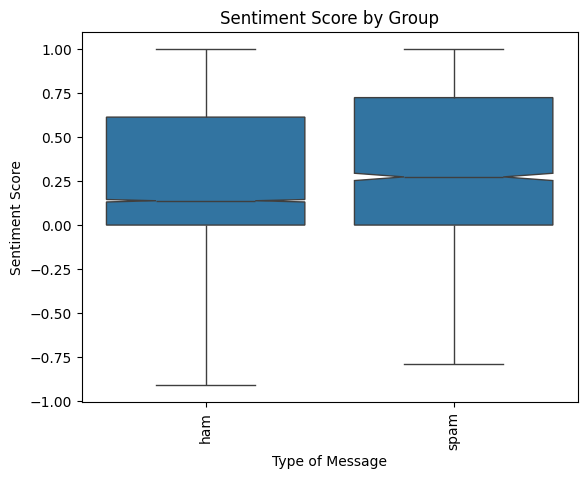

In [24]:
import seaborn as sns
# Create seaborn boxplots by group
sns.boxplot(x='Label', y='sentiment_score', notch = True,
            data=df_output, showfliers=False).set(title='Sentiment Score by Group')
# Codify axis labels
plt.xlabel('Type of Message')
plt.ylabel('Sentiment Score')
plt.xticks(rotation=90)

In [25]:
# Redo graphs using Altair package
import altair as alt

# Prepare data for mean sentiment score by Message Type
dfg_type = df_output.groupby('Label')['sentiment_score'].mean().reset_index()
dfg_type['Label'] = dfg_type['Label'].astype(str).str.replace(r'\.0$', '', regex=True)

# Create the Altair bar chart for Sentiment Score by Type
chart_type = alt.Chart(dfg_type).mark_bar().encode(
    x=alt.X('Label:N', title='Type'), # Use :N for nominal (categorical) data
    y=alt.Y('sentiment_score:Q', title='Mean Sentiment Score'),
    color=alt.Color('Label:N', legend=alt.Legend(title="type")),
    tooltip=['Label', 'sentiment_score']
).properties(
    title='Mean Sentiment Score by Message Type'
).interactive()

chart_type

alt.Chart(...)

In [26]:
# Histogram with Altair

# Fix error of # of rows in dataset greater than max allowed
df_small = df_output.sample(n=4000, random_state=42)

# Create the Altair histogram
chart_hist = alt.Chart(df_small).mark_bar().encode(
    alt.X('sentiment_score:Q', bin=alt.Bin(maxbins=30), title='Sentiment Score'),
    alt.Y('count()', title='Frequency'),
    tooltip=['sentiment_score']
).properties(
    title='Histogram of Sentiment Score'
).interactive()

chart_hist

alt.Chart(...)

### Questions:

#### What is the 'text' field for your dataset?

The 'text' field I chose for my dataset is the "Message" column. This column contains all the SMS messages that will be used for the sentiment analysis.

#### Which common column did you choose to merge your original dataset with the sentiment scores?

The common column I chose to merge in the original dataset with the sentiment score was the index column. This allows each sentiment score to be correctly aligned with its corresponding message and to avoid duplication when merging.

#### Briefly explain your sentiment polarity results using the `describe` method.

The 'describe' method shows the distribution of the sentiment analysis score. It shows the mean representation of the sentiment score across the averages from all messages. With the distribution of this dataset, the spam messages have a score of 0.36, which is overall a higher sentiment score compared to the ham messages, which have a score of 0.29. Both message types are in the positive and indicate an overall positive sentiment, but spam messages have overall higher scores compared to ham messages.

#### Visualize and explain your sentiment result using two different visualization libaries.

Above, it can be observed that the bar chart was used to compare the average sentiment score between ham and spam messages. This showed the difference in tone between the two categories. Next, there is a histogram that was used to visualize the distribution of the sentiment scores. The histogram shows the number of messages (frequency) for each sentiment score. When interpreting the histogram, majority of the messages fall in 0, meaning the majority of the messages are neutral. The next bunch would be in the positive, meaning most of the messages have a positive/uplifting message. The last graph shown is a boxplot, which calls the seaborn package,  to compare the spread and variability of the sentiment scores between the two groups. This shows the median values of each group as well as the interquartile ranges. Following the three graphs, the Altair package is called to graph an additional bar graph and a histogram. Both show the same results previously, except using a different package.

## Task 2: Conclusion

### What went well? What did not go well, or what challenges did you encounter?

During this lab, implementing the sentiment analysis and generating the plots went smoothly. It was helpful to have some guidance when doing the lab. One of the initial problems I encountered has to do with merging the data. Initially, merging with the non-unique column caused duplication issues and incorrect results, causing a large skew in data. When running the initial code, I received 400,000 frequencies in the histogram, which was the result of the duplication issue. Another challenge I encountered was with the Altair package and the histogram. There were issues with the limitation of rows and rendering issues. The error I received was "MaxRowsError: The number of rows in your dataset is greater than the maximum allowed (5000)." To fix this, I had to adjust my dataset to be smaller before running the plot. The Altair histogram distribution still follows the same shape as the histogram distribution of the other histogram.

### In what ways could sentiment analysis be integrated into your current or future professional or research work?

Sentiment analysis could be integrated into my future work by providing feedback or user review analysis to gain some insight into the public opinion. This can also help with my future work by improving the decision making process in the engineering space. For example, if in the future, I create some kind of product or software and want to recieve input. I would implement a sentiment analysis after organizing all the feedback into a dataset to see the overall distribution of the positive, negatives, or neutral feedback.